# 11 - Hydrological Analysis with the `Hydrological` Class

This is the main notebook of the `TimeSeries` hydrology tour. It walks through the
methods used daily by hydrologists, water-resource engineers and flood-risk analysts.
We assume **no prior statistical knowledge** - each concept is explained before use.

## 1. What is a hydrological time series?

A **streamflow** (or **discharge**) time series is the volume of water passing a river
cross-section per unit time, usually measured in cubic metres per second (m^3/s).
Such series have a few features that make them special:

1. **Strongly skewed** - most days have modest flow, but a few days carry enormous
   flood peaks. The mean is therefore a poor summary.
2. **Seasonal** - driven by rainfall, snowmelt and evaporation.
3. **Auto-correlated** - today's flow depends on yesterday's (the catchment has memory).
4. **Non-negative** - flow cannot be below zero.
5. **Two regimes coexist** - a slow *baseflow* coming from groundwater, and fast
   *quickflow* produced by rainfall events.

Because of these features, general-purpose statistics (mean, std, normal distribution)
are usually misleading. The `Hydrological` mixin provides tools tailored to these data.

## 2. Load real discharge data

We use `rhine-full-time-series.csv`, which contains daily discharge at
several gauges along the Rhine and its tributaries from 1955 to 2013 -
almost 60 years of data. We will focus on the gauge at **Cologne**, one of
the longest and best-documented records in Europe.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statista.time_series import TimeSeries

DATA = '../../../examples/data/rhine-full-time-series.csv'
raw = pd.read_csv(DATA, parse_dates=['date'], index_col='date')
print('Available gauges:', list(raw.columns))
print('Period          :', raw.index.min().date(), '->', raw.index.max().date())

Available gauges: ['rees', 'cologne', 'andernach', 'trier', 'cochem', 'marburg', 'kaub', 'mainz', 'frankfurt', 'kleinheubach', 'steinbach', 'schweinfurt', 'worms', 'speyer', 'maxau', 'rockenau', 'lauffen', 'plochingen']
Period          : 1955-01-01 -> 2013-01-05


In [2]:
# Focus on Cologne and drop missing values
cologne = raw[['cologne']].dropna()
print('Valid records at Cologne:', len(cologne))
ts = TimeSeries(cologne)
ts.head()

Valid records at Cologne: 21188


,cologne
date,
1955-01-03,8.232
1955-01-04,402.684
1955-01-05,807.674
1955-01-06,1126.068
1955-01-07,1243.997


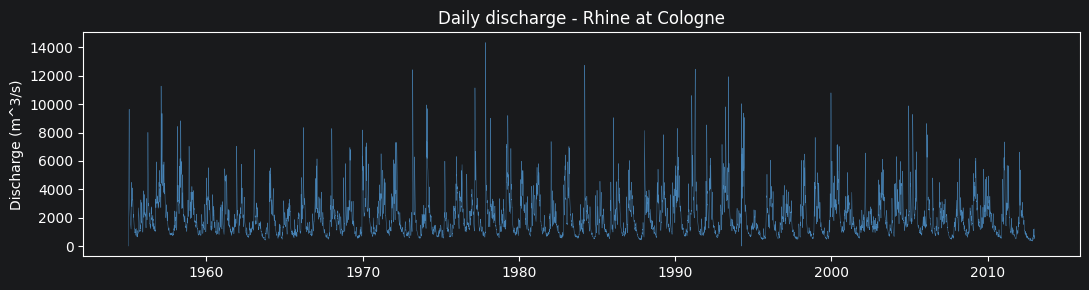

In [3]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(ts.index, ts['cologne'].values, linewidth=0.3, color='steelblue')
ax.set_title('Daily discharge - Rhine at Cologne')
ax.set_ylabel('Discharge (m^3/s)')
plt.tight_layout()
plt.show()

Notice the spiky floods on top of a slowly-varying baseflow. That contrast
is exactly what the methods below are designed to analyse.

## 3. `.flow_duration_curve()` - the signature plot of hydrology

The **Flow Duration Curve (FDC)** is, by a wide margin, the most-used plot
in hydrology. It answers:

> *What percentage of time is a given flow equalled or exceeded?*

Construction is very simple:

1. Sort all flows from largest to smallest.
2. Assign a rank i (1 = largest).
3. Compute the **exceedance probability** P(i) using a *plotting position*
   formula.
4. Plot Q (flow) against P (in %). Usually Q is on a **log axis** so that
   low flows (important for droughts) and high flows (important for floods)
   are both visible.

### Plotting position formulas

| Name | Formula | When to use |
|---|---|---|
| Weibull | `i / (n+1)` | The classic default. |
| Gringorten | `(i-0.44) / (n+0.12)` | Optimal for Gumbel / GEV extremes. |
| Cunnane | `(i-0.4) / (n+0.2)` | Compromise, nearly unbiased for most distributions. |

### Key percentile flows

- **Q10** - the flow exceeded only 10% of the time (high flow, close to floods).
- **Q50** - the median flow.
- **Q90** - the flow exceeded 90% of the time (low flow, drought indicator).
- **Q95 - Q99** - used to design minimum ecological releases.

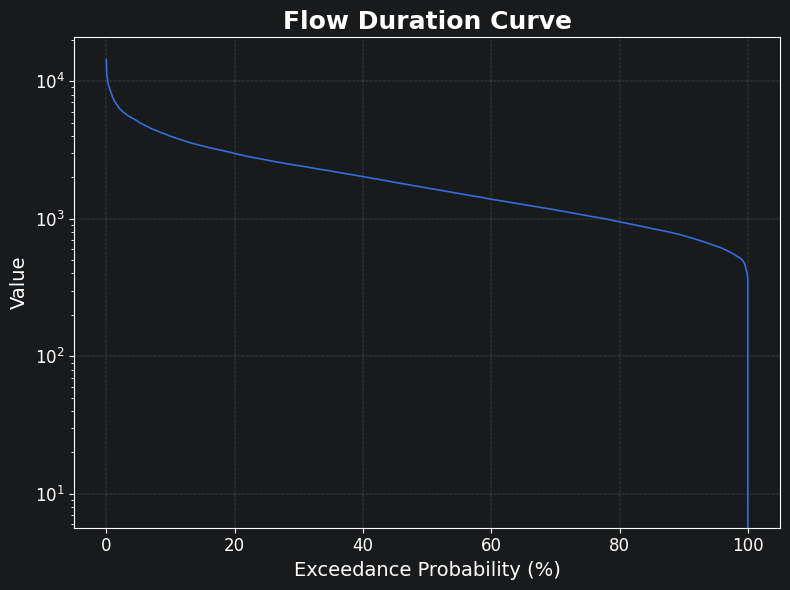

In [4]:
fdc, _ = ts.flow_duration_curve(column='cologne', method='weibull', log_scale=True)

In [5]:
# Read off Q10, Q50, Q90 directly
def q_at(df, pct):
    # Interpolate the flow corresponding to a given exceedance percentage
    idx = (df['exceedance_pct'] - pct).abs().idxmin()
    return float(df.loc[idx, 'value'])

print(f'Q10 (high flow)   = {q_at(fdc, 10):8.1f} m^3/s')
print(f'Q50 (median flow) = {q_at(fdc, 50):8.1f} m^3/s')
print(f'Q90 (low flow)    = {q_at(fdc, 90):8.1f} m^3/s')
print(f'Q95 (drought)     = {q_at(fdc, 95):8.1f} m^3/s')

Q10 (high flow)   =   3981.2 m^3/s
Q50 (median flow) =   1671.6 m^3/s
Q90 (low flow)    =    752.0 m^3/s
Q95 (drought)     =    632.5 m^3/s


### Interpretation

- **Q10 / Q50 ratio** - measures how flashy the river is. A ratio near 1
  means steady flow, a large ratio (> 3) means strong peaks.
- **Q90 / Q50 ratio** - measures how well the river is sustained during dry
  periods. A high value (> 0.3) indicates good baseflow from groundwater.

Comparing the Weibull and Gringorten plotting positions shows that the
assigned exceedance probabilities at the tails differ - this matters when
fitting extreme-value distributions later.

In [6]:
fdc_g, _ = ts.flow_duration_curve(column='cologne', method='gringorten', plot=False)
print('Highest flow Weibull exceedance (%) :', round(fdc['exceedance_pct'].iloc[0], 3))
print('Highest flow Gringorten exceedance (%):', round(fdc_g['exceedance_pct'].iloc[0], 3))

Highest flow Weibull exceedance (%) : 0.005
Highest flow Gringorten exceedance (%): 0.003


## 4. `.annual_extremes(kind='max')` - building a flood series

For flood-frequency analysis we reduce the full record to the single
**largest flow per year** - the so-called **Annual Maximum Series (AMS)**.

### The water-year concept

In many catchments, especially snow-dominated ones, a *hydrological year*
(or *water year*) does not coincide with the calendar year. A common choice
is **October 1 - September 30**, so that winter storms and spring snowmelt
fall in the same water year. The argument `water_year_start='YE-OCT'` tells
`.annual_extremes()` to resample accordingly.

In [7]:
ams = ts.annual_extremes(kind='max', water_year_start='YE-OCT', column='cologne')
print('Number of annual maxima:', len(ams))
print(ams.head())

Number of annual maxima: 59
              cologne
date                 
1955-10-31   9646.573
1956-10-31   8013.303
1957-10-31  11275.737
1958-10-31   8832.547
1959-10-31   7032.505


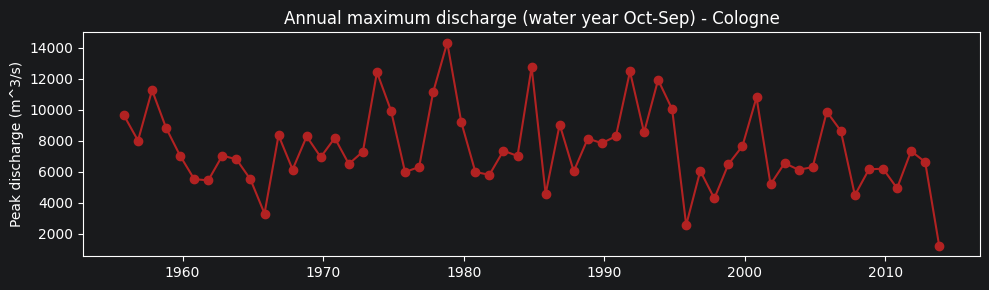

In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ams.index, ams['cologne'], 'o-', color='firebrick')
ax.set_title('Annual maximum discharge (water year Oct-Sep) - Cologne')
ax.set_ylabel('Peak discharge (m^3/s)')
plt.tight_layout()
plt.show()

## 5. `.exceedance_probability()` - turning flows into return periods

### What is a return period?

The **return period T** of a flood is the *average* number of years between
events of that size or larger. A **100-year flood** is one with an annual
exceedance probability of 1/100 = 0.01 - meaning that in any given year there
is a 1% chance of seeing a flood that big or bigger. It does **not** mean
"exactly one every 100 years"; two 100-year floods can occur in the same
decade, just as two sixes can appear on two consecutive dice rolls.

The relationship is simply `T = 1 / P`, where P is the exceedance
probability on an annual basis.

In [9]:
exc = ams.exceedance_probability(method='weibull', column='cologne')
print(exc.head())

    column      value  exceedance_probability  return_period
0  cologne  14343.887                0.016667           60.0
1  cologne  12749.353                0.033333           30.0
2  cologne  12474.135                0.050000           20.0
3  cologne  12428.656                0.066667           15.0
4  cologne  11938.091                0.083333           12.0


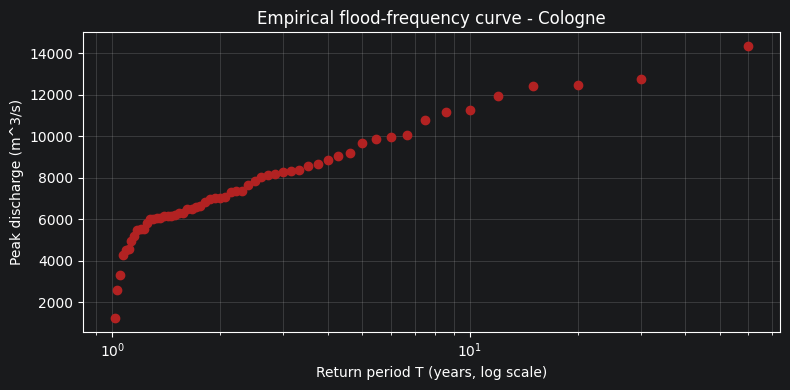

In [10]:
# Empirical return period associated with each observed AMS value
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(exc['return_period'], exc['value'], 'o', color='firebrick')
ax.set_xlabel('Return period T (years, log scale)')
ax.set_ylabel('Peak discharge (m^3/s)')
ax.set_title('Empirical flood-frequency curve - Cologne')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Baseflow vs. quickflow - the physics

Total streamflow `Q` can be decomposed into two parts:

- **Baseflow (b)** - slow, groundwater-fed contribution that persists
  between rainfall events. It drains from aquifers, so it decays
  exponentially (Q ~ Q0 * exp(-t/k)).
- **Quickflow (q)** - fast runoff produced by recent rainfall or snowmelt.
  It is responsible for the sharp peaks of the hydrograph.

Separating them is useful because:

- *Baseflow* is the reliable, year-round supply - crucial for water-supply
  planning and ecological minima.
- *Quickflow* drives floods, erosion, and pollutant wash-off.

Perfect separation is impossible from streamflow alone, so we use digital
filters that apply a physically-motivated rule to assign, at each time step,
a portion of Q to the baseflow.

## 7. `.baseflow_separation(method='lyne_hollick')` - one-parameter filter

Lyne & Hollick (1979) proposed the recursion

`b_t = alpha * b_{t-1} + (1 - alpha) / 2 * (q_t + q_{t-1})`

constrained by `0 <= b_t <= q_t`. The parameter `alpha` in [0, 1] controls
how slowly baseflow responds to rainfall. Typical values are 0.90-0.95.
Larger alpha = smoother / slower baseflow.

In [11]:
lh_df, _ = ts.baseflow_separation(method='lyne_hollick', alpha=0.925,
                                  column='cologne', plot=False)
print(lh_df.head())
print('\nMean baseflow  :', round(lh_df['baseflow'].mean(), 1), 'm^3/s')
print('Mean quickflow :', round(lh_df['quickflow'].mean(), 1), 'm^3/s')

            total_flow    baseflow    quickflow
date                                           
1955-01-03       8.232    8.232000     0.000000
1955-01-04     402.684   23.023950   379.660050
1955-01-05     807.674   66.685579   740.988421
1955-01-06    1126.068  134.199485   991.868515
1955-01-07    1243.997  213.011961  1030.985039

Mean baseflow  : 1765.7 m^3/s
Mean quickflow : 334.8 m^3/s


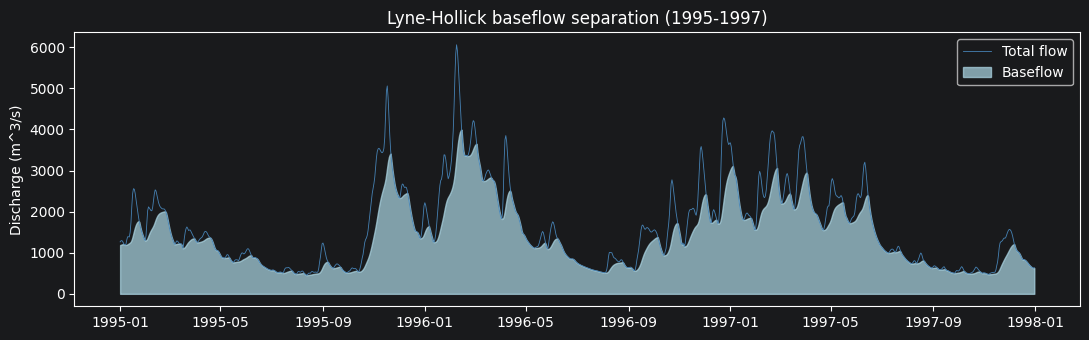

In [12]:
# Show a 3-year window so individual events are visible
window = lh_df.loc['1995':'1997']
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(window.index, window['total_flow'], color='steelblue', linewidth=0.6, label='Total flow')
ax.fill_between(window.index, 0, window['baseflow'], color='lightblue', alpha=0.7, label='Baseflow')
ax.set_title('Lyne-Hollick baseflow separation (1995-1997)')
ax.set_ylabel('Discharge (m^3/s)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. `.baseflow_separation(method='eckhardt')` - two-parameter filter

Eckhardt (2005) refined the Lyne-Hollick filter by adding a maximum baseflow
index parameter `bfi_max` that limits the fraction of total flow which can
come from baseflow. Typical values:

- 0.80 for perennial streams with porous aquifers
- 0.50 for perennial streams with hard-rock aquifers
- 0.25 for ephemeral streams

The recursion is:

`b_t = ((1 - BFImax) * alpha * b_{t-1} + (1 - alpha) * BFImax * q_t) / (1 - alpha * BFImax)`

In [13]:
ek_df, _ = ts.baseflow_separation(method='eckhardt', alpha=0.98, bfi_max=0.80,
                                  column='cologne', plot=False)
print('Eckhardt mean baseflow :', round(ek_df['baseflow'].mean(), 1), 'm^3/s')
print('Eckhardt mean quickflow:', round(ek_df['quickflow'].mean(), 1), 'm^3/s')

Eckhardt mean baseflow : 1624.5 m^3/s
Eckhardt mean quickflow: 476.0 m^3/s


## 9. `.baseflow_separation(method='chapman_maxwell')` - simpler alternative

Chapman & Maxwell (1996) provide a minimalistic one-parameter recursion:

`b_t = k/(2-k) * b_{t-1} + (1-k)/(2-k) * q_t`

It tends to produce higher baseflow than Lyne-Hollick for the same `k`.

In [14]:
cm_df, _ = ts.baseflow_separation(method='chapman_maxwell', alpha=0.925,
                                  column='cologne', plot=False)
print('Chapman-Maxwell mean baseflow:', round(cm_df['baseflow'].mean(), 1), 'm^3/s')

Chapman-Maxwell mean baseflow: 1049.0 m^3/s


## 10. `.baseflow_index()` - a single number to summarise a catchment

The **Baseflow Index (BFI)** is defined as

`BFI = sum(baseflow) / sum(total_flow)`

and it takes values in [0, 1]:

- **BFI -> 1** : groundwater-dominated, very steady rivers (chalk streams,
  karstic springs).
- **BFI -> 0** : flashy, surface-runoff dominated (steep, urbanised,
  impermeable catchments).

BFI is widely used in regionalisation studies to predict flow in ungauged
basins and to compare catchments.

In [15]:
bfi_lh = ts.baseflow_index(method='lyne_hollick', column='cologne')
bfi_ek = ts.baseflow_index(method='eckhardt', column='cologne')
bfi_cm = ts.baseflow_index(method='chapman_maxwell', column='cologne')
print('BFI (Lyne-Hollick)   :', round(float(bfi_lh['bfi'].iloc[0]), 3))
print('BFI (Eckhardt)       :', round(float(bfi_ek['bfi'].iloc[0]), 3))
print('BFI (Chapman-Maxwell):', round(float(bfi_cm['bfi'].iloc[0]), 3))

BFI (Lyne-Hollick)   : 0.841
BFI (Eckhardt)       : 0.799
BFI (Chapman-Maxwell): 0.499


The three methods give different but comparable BFI values. For the Rhine
at Cologne the BFI lies in the 0.5-0.7 range, which is typical of a large
mixed-regime river fed by Alpine snowmelt and lowland rainfall.

## 11. `.flashiness_index()` - Richards-Baker index

The Richards-Baker (RB) flashiness index quantifies how oscillatory a flow
series is:

`FI = sum( |Q_t - Q_{t-1}| ) / sum( Q_t )`

- Low values (< 0.1) : slowly-varying river (e.g. large, groundwater-fed).
- High values (> 1) : very flashy (small urban streams, arid watersheds).

It complements the BFI: together they give a compact summary of the flow
regime.

In [16]:
fi = ts.flashiness_index(column='cologne')
print('Richards-Baker FI at Cologne:', round(float(fi['flashiness'].iloc[0]), 4))

Richards-Baker FI at Cologne: 0.0557


## 12. `.recession_analysis()` - fitting exponential decay

Between rainfall events the river flow decays as the aquifer drains. If the
aquifer behaves as a linear reservoir, the decay is exponential:

`Q(t) = Q0 * exp(-t / k)`

The **recession constant k** (in days) is a key catchment characteristic:

- Small k (a few days) : fast-draining, shallow stores - mountain streams.
- Large k (tens to hundreds of days) : deep, slow aquifers - chalk, karst.

The method identifies monotonically decreasing segments at least `min_length`
days long and fits `log(Q) = log(Q0) - t/k` by linear regression. The
**R-squared** of each fit tells how close to a pure exponential the recession
is (close to 1 = perfectly linear reservoir).

In [17]:
# Use a sub-period so the plot stays readable
ts_sub = TimeSeries(ts['cologne'].loc['2000':'2005'].to_frame(name='cologne'))
rec_df, _ = ts_sub.recession_analysis(min_length=7, column='cologne', plot=False)
print('Number of recession segments found:', len(rec_df))
print(rec_df.head())
print('\nMedian recession constant k (days):',
      round(float(rec_df['recession_constant_k'].median()), 1))

Number of recession segments found: 101
   recession_id  start_index  end_index  length  recession_constant_k  \
0             0            0          8       9             17.178610   
1             1           13         30      18             14.718160   
2             2           43         59      17             16.051949   
3             3           68         78      11             14.808471   
4             4           88        101      14             47.281637   

   r_squared  
0   0.970872  
1   0.974280  
2   0.981054  
3   0.978972  
4   0.991471  

Median recession constant k (days): 23.0


The median value of k summarises the dominant drainage time scale of the
upstream aquifer system. For large Alpine rivers like the Rhine we typically
expect k on the order of tens of days.

---

## Summary

| Method | What it gives you | Typical use |
|---|---|---|
| `flow_duration_curve` | Exceedance of every flow | Design, ecology, comparison |
| `annual_extremes` | AMS / AMIN series | Flood / drought frequency |
| `exceedance_probability` | Empirical P and return period T | Flood-frequency plots |
| `baseflow_separation` | Baseflow / quickflow hydrograph | Event analysis, water balance |
| `baseflow_index` | Single BFI number | Catchment regionalisation |
| `flashiness_index` | RB index | Flow variability quantification |
| `recession_analysis` | k (days), R^2 | Aquifer / drainage characterisation |

Together these methods give a quantitative fingerprint of any streamflow
record and are the starting point of almost every operational hydrological
study.